## Load results
Allow loading results from multiple folders

In [18]:
import os
import pickle

def load_result_dicts(dirs, whitelist=None, blacklist=None, equivalence_dict=None, include_trivia=True):
    """
    Combine results from multiple sweep directories
    """

    all_dicts = {}
    for dir_path in dirs:
        print(f"Loading results from {dir_path}")
        # get names of all children of dir_path, which are format *dict.pkl
        all_files = os.listdir(dir_path)
        dict_files = [f for f in all_files if f.endswith('dict.pkl')]
        for f in dict_files:
            shortened_name = f.split('_dict.pkl')[0]
            if shortened_name not in all_dicts:
                all_dicts[shortened_name] = {}

            d = pickle.load(open(os.path.join(dir_path, f), 'rb')) # d is a dictionary of {model_name: model_results}
            print(f"Loading from {dir_path}/{f}")

            if "trivia" in shortened_name.lower() and include_trivia:
                # fix trivia dictionary
                # nested dictionary with "hard" and "easy" keys, {model_name: trivia_score} as values
                # need change to model_name on outside, {"hard": score, "easy": score} on inside
                new_d = {}
                for difficulty in d:
                    for model_name in d[difficulty]:
                        if model_name not in new_d:
                            new_d[model_name] = {}
                        new_d[model_name][difficulty] = d[difficulty][model_name]
                d = new_d

            if shortened_name in all_dicts:
                # update the all_dicts[f] with all the keys in d
                # for k in d:
                #     all_dicts[shortened_name][k] = d[k]
                for k in d:
                    model_name = k
                    if equivalence_dict is not None and k in equivalence_dict:
                        model_name = equivalence_dict[k]
                    if whitelist is not None and model_name not in whitelist:
                        continue
                    if blacklist is not None and model_name in blacklist:
                        continue
                    if model_name in all_dicts[shortened_name]:
                        all_dicts[shortened_name][model_name].update(d[k])
                    else:
                        all_dicts[shortened_name][model_name] = d[k]
                # all_dicts[shortened_name].update(d)
            else:
                # add it to the all_dicts
                # all_dicts[shortened_name] = d
                for k in d:
                    model_name = k
                    if equivalence_dict is not None and k in equivalence_dict:
                        model_name = equivalence_dict[k]
                    if whitelist is not None and model_name not in whitelist:
                        continue
                    if blacklist is not None and model_name in blacklist:
                        continue
                    all_dicts[shortened_name][model_name] = d[k]
                
    return all_dicts



In [21]:
# all_dicts = load_result_dicts(["results/llama-lat-less-noise", "results/llama-lat-less-noise-2", "results/pca-ultrachat-final-sweep-sft_type=harmless"], whitelist=["WHP", "WHP_Replication", "WHP_All_Coefs", 'PCA_L10_Eps0.1', 'PCA_L15_Eps0.1', 'PCA_L20_Eps0.1', 'PCA_L10_Eps1.0', 'PCA_L15_Eps1.0', 'PCA_L20_Eps1.0', 'PCA_L10_Eps10.0', 'PCA_L15_Eps10.0', 'PCA_L20_Eps10.0', "WHP_Original"], equivalence_dict={"WHP": "WHP_Original"})
# all_dicts = load_result_dicts(["results/llama-lat-less-noise-2", "results/pca-ultrachat-final-sweep-sft_type=harmless", "results/pca-harmless-multi-run"], whitelist=['WHP_Replication_1', 'WHP_All_Coefs_1', 'PCA_L15_Def15_Eps10_1', 'PCA_L15_Def0_Eps10_1', 'PCA_L10_Def10_Eps0.1_1', 'PCA_L10_Def0_Eps0.1_1', 'WHP_Replication_2', 'WHP_All_Coefs_2', 'PCA_L15_Def15_Eps10_2', 'PCA_L15_Def0_Eps10_2', 'PCA_L10_Def10_Eps0.1_2', 'PCA_L10_Def0_Eps0.1_2', 'WHP_Replication_3', 'WHP_All_Coefs_3', 'PCA_L15_Def15_Eps10_3', 'PCA_L15_Def0_Eps10_3', 'PCA_L10_Def10_Eps0.1_3', 'PCA_L10_Def0_Eps0.1_3', 'LLaMA', 'WHP_Original'], equivalence_dict={"WHP": "WHP_Original"})
all_dicts = load_result_dicts([
    "results/llama-lat-less-noise-2", "results/pca-ultrachat-final-sweep-sft_type=harmless", "results/pca-harmless-multi-run",
"results/pca-harmless-multi-run", "results/pca-ultrachat-baselines-run", "results/pca-ultrachat-multi-run", "results/pca-ultrachat-towards_only-multi-run"
], whitelist=['WHP_Replication_4', 'WHP_All_Coefs_4', 'Eps0.5_4', 'Eps1.5_4', 'Eps3.0_4', 'Eps6.0_4', 'WHP_Replication_5', 'WHP_All_Coefs_5', 'Eps0.5_5', 'Eps1.5_5', 'Eps3.0_5', 'Eps6.0_5', 'WHP_Replication_6', 'WHP_All_Coefs_6', 'Eps0.5_6', 'Eps1.5_6', 'Eps3.0_6', 'Eps6.0_6', 'Eps0.5_TowardsOnly_4', 'Eps1.5_TowardsOnly_4', 'Eps3.0_TowardsOnly_4', 'Eps6.0_TowardsOnly_4', 'Eps0.5_TowardsOnly_5', 'Eps1.5_TowardsOnly_5', 'Eps3.0_TowardsOnly_5', 'Eps6.0_TowardsOnly_5', 'Eps0.5_TowardsOnly_6', 'Eps1.5_TowardsOnly_6', 'Eps3.0_TowardsOnly_6', 'Eps6.0_TowardsOnly_6','LLaMA', 'WHP_Original'], equivalence_dict={"WHP": "WHP_Original"})

Loading results from results/llama-lat-less-noise-2
Loading from results/llama-lat-less-noise-2/capability_dict.pkl
Loading from results/llama-lat-less-noise-2/full_capability_dict.pkl
Loading from results/llama-lat-less-noise-2/spanish_familiarity_dict.pkl
Loading from results/llama-lat-less-noise-2/summary_style_dict.pkl
Loading from results/llama-lat-less-noise-2/trivia_dict.pkl
Loading from results/llama-lat-less-noise-2/dan_adversarial_dict.pkl
Loading from results/llama-lat-less-noise-2/familiarity_dict.pkl
Loading results from results/pca-ultrachat-final-sweep-sft_type=harmless
Loading from results/pca-ultrachat-final-sweep-sft_type=harmless/familiarity_dict.pkl
Loading from results/pca-ultrachat-final-sweep-sft_type=harmless/trivia_dict.pkl
Loading from results/pca-ultrachat-final-sweep-sft_type=harmless/summary_style_dict.pkl
Loading from results/pca-ultrachat-final-sweep-sft_type=harmless/dan_adversarial_dict.pkl
Loading from results/pca-ultrachat-final-sweep-sft_type=harmles

In [23]:
print(all_dicts['familiarity'].keys())
print(all_dicts['trivia'].keys())
print(all_dicts['full_capability'].keys())
print(all_dicts['summary_style'].keys())
print(all_dicts['spanish_familiarity'].keys())
print(all_dicts['dan_adversarial'].keys())
print(all_dicts['text_lines'].keys())

dict_keys(['LLaMA', 'WHP_Original', 'WHP_Replication_4', 'WHP_All_Coefs_4', 'Eps0.5_4', 'Eps1.5_4', 'Eps3.0_4', 'Eps6.0_4', 'WHP_Replication_5', 'WHP_All_Coefs_5', 'Eps0.5_5', 'Eps1.5_5', 'Eps3.0_5', 'Eps6.0_5', 'WHP_Replication_6', 'WHP_All_Coefs_6', 'Eps0.5_6', 'Eps1.5_6', 'Eps3.0_6', 'Eps6.0_6', 'Eps0.5_TowardsOnly_4', 'Eps1.5_TowardsOnly_4', 'Eps3.0_TowardsOnly_4', 'Eps6.0_TowardsOnly_4', 'Eps0.5_TowardsOnly_5', 'Eps1.5_TowardsOnly_5', 'Eps3.0_TowardsOnly_5', 'Eps6.0_TowardsOnly_5', 'Eps0.5_TowardsOnly_6', 'Eps1.5_TowardsOnly_6', 'Eps3.0_TowardsOnly_6', 'Eps6.0_TowardsOnly_6'])
dict_keys(['LLaMA', 'WHP_Original', 'WHP_Replication_4', 'WHP_All_Coefs_4', 'Eps0.5_4', 'Eps1.5_4', 'Eps3.0_4', 'Eps6.0_4', 'WHP_Replication_5', 'WHP_All_Coefs_5', 'Eps0.5_5', 'Eps1.5_5', 'Eps3.0_5', 'Eps6.0_5', 'WHP_Replication_6', 'WHP_All_Coefs_6', 'Eps0.5_6', 'Eps1.5_6', 'Eps3.0_6', 'Eps6.0_6', 'Eps0.5_TowardsOnly_4', 'Eps1.5_TowardsOnly_4', 'Eps3.0_TowardsOnly_4', 'Eps6.0_TowardsOnly_4', 'Eps0.5_Towards

# Analyzing LAT familiarity + Adversarial Testing results

In [26]:
def get_familiarity_score(dict):
    try:
        overall_dict = {}
        for key in dict:
            total_responses = dict[key].get(0) + dict[key].get(1) + dict[key].get(2) + dict[key].get(3)
            total_correct = dict[key].get(2) / 5 + dict[key].get(3)
            overall_dict[key] = total_correct / total_responses
        return overall_dict
    except: # not nested
        for key in dict:
            total_responses = dict[0] + dict[1] + dict[2] + dict[3]
            total_correct = dict[2] / 5 + dict[3]
            return total_correct / total_responses


In [47]:
default_aggregated_names = ['WHP_Replication', 'WHP_All_Coefs', 'Eps0.5', 'Eps1.5', 'Eps3.0', 'Eps6.0', 'Eps0.5_TowardsOnly', 'Eps1.5_TowardsOnly', 'Eps3.0_TowardsOnly', 'Eps6.0_TowardsOnly']
run_ids = [4, 5, 6]

from collections import defaultdict
def combine_runs(model_responses_dict, aggregated_model_names=default_aggregated_names, run_ids=run_ids, whitelist_passthrough=['WHP_Original', 'LLaMA']):
    aggregated_familiarity_scores = {}
    for model_name in aggregated_model_names:
        aggregated_familiarity_scores[model_name] = {}
        for run_id in run_ids:
            key = f"{model_name}_{run_id}"
            if key in model_responses_dict:
                # if the values of model_responses_dict[key] are dictionaries, then it is a nested dictionary with outer keys of run_type (e.g. short vs long). Else, if the values are just integers, then it is not nested
                if isinstance(list(model_responses_dict[key].values())[0], dict):
                    
                    for inner_key in model_responses_dict[key]:
                        if inner_key in aggregated_familiarity_scores[model_name]:
                            for model_response in model_responses_dict[key][inner_key]:
                                if model_response in aggregated_familiarity_scores[model_name][inner_key]:
                                    aggregated_familiarity_scores[model_name][inner_key][model_response] += model_responses_dict[key][inner_key][model_response]
                                else:
                                    aggregated_familiarity_scores[model_name][inner_key][model_response] = model_responses_dict[key][inner_key][model_response]
                            # aggregated_familiarity_scores[model_name][inner_key].update(model_responses_dict[key][inner_key])
                        else:
                            aggregated_familiarity_scores[model_name][inner_key] = model_responses_dict[key][inner_key]
                else:
                    for model_response in model_responses_dict[key]:
                        if model_response in aggregated_familiarity_scores[model_name]:
                            aggregated_familiarity_scores[model_name][model_response] += model_responses_dict[key][model_response]
                        else:
                            aggregated_familiarity_scores[model_name][model_response] = model_responses_dict[key][model_response]
            else:
                print(f"Key {key} not found in model_responses_dict")
            # aggregated_familiarity_scores.append(familiarity_scores_dict[key])
    for model_name in model_responses_dict:
        if model_name in whitelist_passthrough:
            aggregated_familiarity_scores[model_name] = model_responses_dict[model_name]

    return aggregated_familiarity_scores

combine_runs(all_dicts['summary_style'])
# def combine_familliarity_scores(model_responses_dict, aggregated_model_names=['WHP_Replication', 'WHP_All_Coefs', 'PCA_L15_Def15_Eps10', 'PCA_L15_Def0_Eps10', 'PCA_L10_Def10_Eps0.1', 'PCA_L10_Def0_Eps0.1'], run_ids=[1,2,3]):
#     aggregated_familiarity_scores = {}
#     for model_name in aggregated_model_names:
#         for run_id in run_ids:
#             key = f"{model_name}_{run_id}"
#             # aggregated_familiarity_scores.append(familiarity_scores_dict[key])
#     return aggregated_familiarity_scores

def combine_capabilities(capability_dict, aggregated_model_names=default_aggregated_names, run_ids=run_ids, whitelist_passthrough=['WHP_Original', 'LLaMA'], allow_capabilities=["mmlu", "sciq"]):
    aggregated_capability_scores = {}
    for model_name in aggregated_model_names:
        aggregated_capability_scores[model_name] = {}
        counts = defaultdict(int)
        
        for run_id in run_ids:
            key = f"{model_name}_{run_id}"
            if key in capability_dict:
                for capability in capability_dict[key]:
                    if capability in allow_capabilities:
                        if capability in aggregated_capability_scores[model_name]:
                            aggregated_capability_scores[model_name][capability] += capability_dict[key][capability]['acc,none']
                            counts[capability] += 1
                        else:
                            aggregated_capability_scores[model_name][capability] = capability_dict[key][capability]['acc,none']
                            counts[capability] += 1
            else:
                print(f"Key {key} not found in capability_dict")
        
        for capability in aggregated_capability_scores[model_name]:
            aggregated_capability_scores[model_name][capability] /= counts[capability]

        # do averaging
    for model_name in whitelist_passthrough:
        if model_name in capability_dict:
            if model_name not in aggregated_capability_scores:
                aggregated_capability_scores[model_name] = {}
            for capability in capability_dict[model_name]:
                if capability in allow_capabilities:
                    aggregated_capability_scores[model_name][capability] = capability_dict[model_name][capability]['acc,none']

    return aggregated_capability_scores

combine_capabilities(all_dicts['full_capability'])

{'WHP_Replication': {'sciq': 0.9336666666666668, 'mmlu': 0.4372833879314437},
 'WHP_All_Coefs': {'sciq': 0.923, 'mmlu': 0.4061862032948773},
 'Eps0.5': {'sciq': 0.9226666666666667, 'mmlu': 0.41430470493282057},
 'Eps1.5': {'sciq': 0.9266666666666667, 'mmlu': 0.41157479941128994},
 'Eps3.0': {'sciq': 0.92, 'mmlu': 0.37717798984000384},
 'Eps6.0': {'sciq': 0.8183333333333334, 'mmlu': 0.3678488344490338},
 'Eps0.5_TowardsOnly': {'sciq': 0.9336666666666668,
  'mmlu': 0.41722451692541423},
 'Eps1.5_TowardsOnly': {'sciq': 0.9196666666666667,
  'mmlu': 0.35866210891136113},
 'Eps3.0_TowardsOnly': {'sciq': 0.9003333333333333,
  'mmlu': 0.27353653325737076},
 'Eps6.0_TowardsOnly': {'sciq': 0.69, 'mmlu': 0.24934719650572093},
 'WHP_Original': {'sciq': 0.943, 'mmlu': 0.44131890044153255},
 'LLaMA': {'sciq': 0.939, 'mmlu': 0.46382281726249824}}

In [13]:
"""
aggregated_familiarity_dict = {}
# save_dir = f"results/llama-lat-sweep-1"
# save_dir = f"results/llama-lat-sweep-2"
# save_dir = f"results/llama-lat-pca-sweep"
# save_dir = f"results/llama-lat-pca-data-sweep"
# save_dir = f"results/lat-data-comparison"
# save_dir = f"results/llama-lat-results-gen-diff-hp-indices"
# models = {"HP-MSR": hp_model}

with open("results/llama-lat-pca-sweep/familiarity_dict.pkl", "rb") as f:
    familiarity_dict = pickle.load(f)
aggregated_familiarity_dict['PCA_L8_Eps1'] = familiarity_dict['PCA_Eps1']
aggregated_familiarity_dict['PCA_L8_Eps10'] = familiarity_dict['PCA_Eps10']
aggregated_familiarity_dict['PCA_L8_Eps100'] = familiarity_dict['PCA_Eps100']

with open("results/llama-lat-pca-data-sweep/familiarity_dict.pkl", "rb") as f:
    familiarity_dict = pickle.load(f)
familiarity_dict
aggregated_familiarity_dict['Pile_PCA_L8_Eps1'] = familiarity_dict['Pile_PCA']
aggregated_familiarity_dict['HP_Only_All_Indices_PCA_L8_Eps1'] = familiarity_dict['HP_Only_All_Indices_PCA']

with open("results/llama-lat-sweep-2/familiarity_dict.pkl", "rb") as f:
    familiarity_dict = pickle.load(f)
familiarity_dict
aggregated_familiarity_dict["No_PCA_L8_Eps1"] = familiarity_dict["WHP_L8_Eps1"]
aggregated_familiarity_dict["No_PCA_L8_Eps10"] = familiarity_dict["WHP_L8_Eps10"]
aggregated_familiarity_dict["No_PCA_L15_Eps1"] = familiarity_dict["WHP_L15_Eps1"]
aggregated_familiarity_dict["No_PCA_L20_Eps1"] = familiarity_dict["WHP_L20_Eps1"]

familiarity_scores = {model: get_familiarity_score(aggregated_familiarity_dict[model]) for model in aggregated_familiarity_dict}

with open("results/final_paper_results/familiarity_dict.pkl", "rb") as f:
    old_familiarity_dict = pickle.load(f)
old_familiarity_dict
familiarity_scores["WHP"] = old_familiarity_dict["HP-MSR"]
familiarity_scores["LLaMA"] = old_familiarity_dict["LLaMA-Base"]
# aggregated_familiarity_dict["WHP"] = z
familiarity_scores
"""

'\naggregated_familiarity_dict = {}\n# save_dir = f"results/llama-lat-sweep-1"\n# save_dir = f"results/llama-lat-sweep-2"\n# save_dir = f"results/llama-lat-pca-sweep"\n# save_dir = f"results/llama-lat-pca-data-sweep"\n# save_dir = f"results/lat-data-comparison"\n# save_dir = f"results/llama-lat-results-gen-diff-hp-indices"\n# models = {"HP-MSR": hp_model}\n\nwith open("results/llama-lat-pca-sweep/familiarity_dict.pkl", "rb") as f:\n    familiarity_dict = pickle.load(f)\naggregated_familiarity_dict[\'PCA_L8_Eps1\'] = familiarity_dict[\'PCA_Eps1\']\naggregated_familiarity_dict[\'PCA_L8_Eps10\'] = familiarity_dict[\'PCA_Eps10\']\naggregated_familiarity_dict[\'PCA_L8_Eps100\'] = familiarity_dict[\'PCA_Eps100\']\n\nwith open("results/llama-lat-pca-data-sweep/familiarity_dict.pkl", "rb") as f:\n    familiarity_dict = pickle.load(f)\nfamiliarity_dict\naggregated_familiarity_dict[\'Pile_PCA_L8_Eps1\'] = familiarity_dict[\'Pile_PCA\']\naggregated_familiarity_dict[\'HP_Only_All_Indices_PCA_L8_Ep

In [14]:
# with open(f"{save_dir}/familiarity_dict.pkl", "rb") as f:
#     familiarity_dict = pickle.load(f)
familiarity_dict = combine_runs(all_dicts['familiarity'])
familiarity_scores = {model: get_familiarity_score(familiarity_dict[model]) for model in familiarity_dict}

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


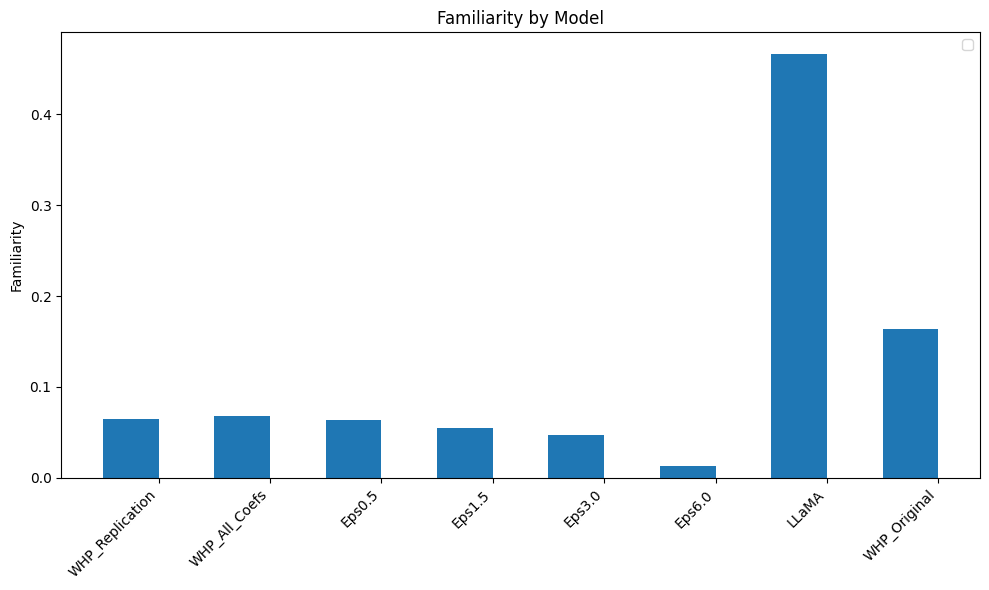

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.5  # width of the bars
index = np.arange(len(familiarity_scores))  # the label locations

# Plot each bar
bars1 = ax.bar(index - bar_width/2, familiarity_scores.values(), bar_width)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Familiarity')
ax.set_title('Familiarity by Model')
ax.set_xticks(index)
ax.set_xticklabels(familiarity_scores.keys(), rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

## Capability vs Familiarity

In [11]:
capability_dict

{'WHP_Replication_1': {'sciq': {'acc,none': 0.936,
   'acc_stderr,none': 0.0077436402269193145,
   'acc_norm,none': 0.896,
   'acc_norm_stderr,none': 0.009658016218524303,
   'alias': 'sciq'},
  'mmlu': {'acc,none': 0.4314912405640222,
   'acc_stderr,none': 0.004026973508746961,
   'alias': 'mmlu'},
  'mmlu_humanities': {'alias': ' - humanities',
   'acc,none': 0.40850159404888414,
   'acc_stderr,none': 0.006911942237861856},
  'mmlu_formal_logic': {'alias': '  - formal_logic',
   'acc,none': 0.2222222222222222,
   'acc_stderr,none': 0.037184890068181146},
  'mmlu_high_school_european_history': {'alias': '  - high_school_european_history',
   'acc,none': 0.5454545454545454,
   'acc_stderr,none': 0.038881769216741},
  'mmlu_high_school_us_history': {'alias': '  - high_school_us_history',
   'acc,none': 0.5882352941176471,
   'acc_stderr,none': 0.0345423658538061},
  'mmlu_high_school_world_history': {'alias': '  - high_school_world_history',
   'acc,none': 0.569620253164557,
   'acc_std

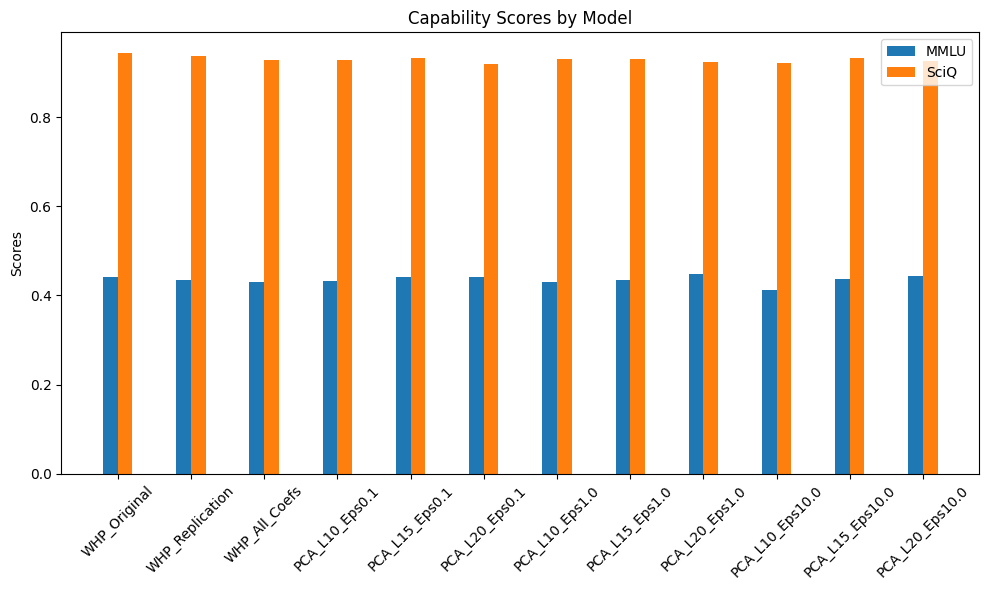

In [12]:
import matplotlib.pyplot as plt
import numpy as np
# with open(f"{save_dir}/capability_dict.pkl", "rb") as f:
#     capability_dict = pickle.load(f)

# Prepare data for MMLU and SciQ for each model
mmlus = {name: accs["mmlu"]['acc,none'] for name, accs in capability_dict.items()}
sciqs = {name: accs["sciq"]['acc,none'] for name, accs in capability_dict.items()}
# piqas = {name: accs["PIQA"] for name, accs in capability_dict.items()}

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.2  # width of the bars
index = np.arange(len(capability_dict))  # the label locations

# Plot each bar
bars1 = ax.bar(index - bar_width/2, mmlus.values(), bar_width, label='MMLU')
bars2 = ax.bar(index + bar_width/2, sciqs.values(), bar_width, label='SciQ')
# bars3 = ax.bar(index + 3*bar_width/2, piqas.values(), bar_width, label='PIQA')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores')
ax.set_title('Capability Scores by Model')
ax.set_xticks(index)
ax.set_xticklabels(capability_dict.keys(), rotation=45,) #ha="right")
ax.legend()

plt.tight_layout()
plt.show()

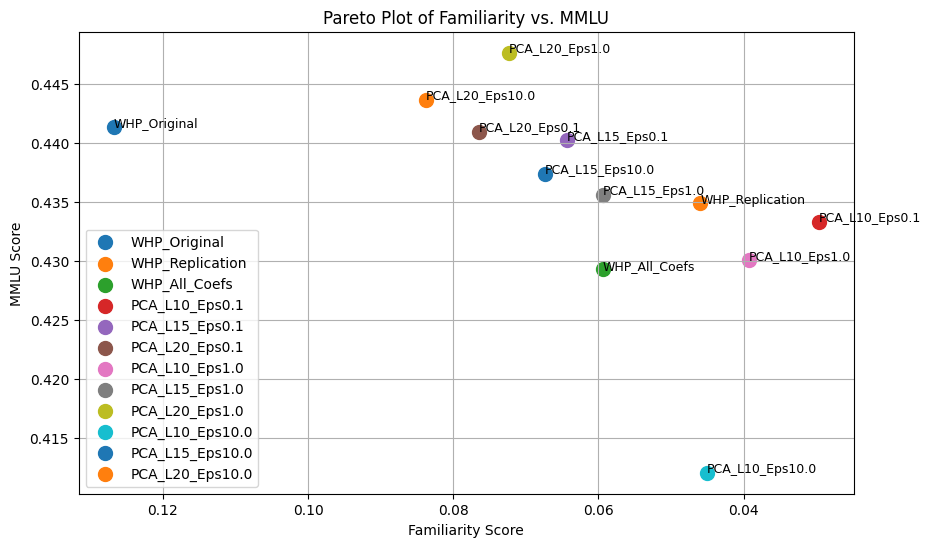

In [13]:
# Plot Pareto Plot, x-axis is familiarity, y-axis is capability
capability_name = "MMLU"
ability_dict = mmlus
ignore_models = ["LLaMA"]
# ignore_models = []

models_list = list(familiarity_scores.keys())  # Assuming familiarity_scores is globally defined and includes all models
colors = plt.cm.get_cmap('tab20', len(models_list))  # 'tab20' is a qualitative colormap with 20 distinct colors
color_map = {model: colors(i) for i, model in enumerate(models_list)}


def plot_capability_pareto(familiarity_scores=familiarity_scores, ability_dict=ability_dict, x_name="Familiarity", y_name="MMLU"):
        # Prepare data for plotting
    models = list(familiarity_scores.keys())
    models = [model for model in models if model not in ignore_models]
    familiarity_values = [familiarity_scores[model] for model in models]
    capability_values = [ability_dict[model] for model in models]

    # Plotting
    plt.figure(figsize=(10, 6))
    for i, model in enumerate(models):
        plt.scatter(familiarity_values[i], capability_values[i], label=model, s=100, color=color_map[model])

    plt.xlabel(f'{x_name} Score')
    plt.ylabel(f'{y_name} Score')
    plt.title(f'Pareto Plot of {x_name} vs. {y_name}')
    plt.legend()

    # Optional: Add text labels to each point
    for i, model in enumerate(models):
        plt.text(familiarity_values[i], capability_values[i], model, fontsize=9)

    plt.grid(True)
    plt.gca().invert_xaxis()  # This line inverts the x-axis
    plt.show()

plot_capability_pareto(ability_dict=mmlus, y_name="MMLU")
# plot_capability_pareto(ability_dict=sciqs, y_name="SciQ")


## Adversarial Results

In [16]:
all_dicts.keys()

dict_keys(['capability', 'full_capability', 'spanish_familiarity', 'summary_style', 'trivia', 'dan_adversarial', 'familiarity', 'text_lines', 'side_effect_familiarity'])

In [17]:
# with open(f"{save_dir}/chat_familiarity_dict.pkl", "rb") as f:
#     chat_familiarity_dict = pickle.load(f)

# with open(f"{save_dir}/dan_adversarial_dict.pkl", "rb") as f:
#     dan_adversarial_dict = pickle.load(f)

# with open(f"{save_dir}/spanish_familiarity_dict.pkl", "rb") as f:
#     spanish_familiarity_dict = pickle.load(f)

# with open(f"{save_dir}/summary_style_dict.pkl", "rb") as f:
#     summary_style_dict = pickle.load(f)

# with open(f"{save_dir}/text_lines_dict.pkl", "rb") as f:
#     text_lines_dict = pickle.load(f)

spanish_familiarity_dict = combine_runs(all_dicts['spanish_familiarity'])
summary_style_dict = combine_runs(all_dicts['summary_style'])

text_lines_dict = combine_runs(all_dicts['text_lines'])
dan_adversarial_dict = combine_runs(all_dicts['dan_adversarial'])

In [18]:
# with open("results/final_paper_results/text_lines_dict.pkl", "rb") as f:
#     old_text_lines_dict = pickle.load(f)
# old_text_lines_dict

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# model_order = list(capability_dict.keys())
model_order = list(familiarity_dict.keys())


# Combine all dictionaries into a single DataFrame
data = []
for name, dict_ in [
    ("Baseline Familiarity", familiarity_dict),
    ("Spanish", spanish_familiarity_dict), 
                    #  ("Chat Prompt", chat_familiarity_dict),
                     ("DAN Prompts", dan_adversarial_dict), 
                     ("Summary Style", summary_style_dict), 
                     ("Text Lines", text_lines_dict)
                      ]:
    for model in model_order:
        # get first key of dict_[model]
        try:
            sample_key = list(dict_[model].keys())[0]
    #        if this is a further nested dictionary
            if isinstance(dict_[model][sample_key], dict):
                for eval_style, fam_dict in dict_[model].items():
                    data.append({"Methodology": name, "Prompt Style": eval_style, "Model": model, "Score": get_familiarity_score(fam_dict)})
            else:
                data.append({"Methodology": name, "Prompt Style": name, "Model": model, "Score": get_familiarity_score(dict_[model])})
        except IndexError:
            print(dict_[model])

        # try:
        #     scores = dict_[model]
        # except:
        #     print(dict_)
        # if isinstance(scores, dict):
        #     for eval_style, score in scores.items():
        #         data.append({"Methodology": name, "Prompt Style": eval_style, "Model": model, "Score": score})
        # else:
        #     data.append({"Methodology": name, "Prompt Style": "Chat", "Model": model, "Score": scores})

# data.append({"Methodology": "Text Lines", "Prompt Style": 2, "Model": "LLaMA", "Score": 1.7941176470588236})
# data.append({"Methodology": "Text Lines", "Prompt Style": 10, "Model": "LLaMA", "Score": 1.9064748201438848})

df = pd.DataFrame(data)
df

,Methodology,Prompt Style,Model,Score
0,Baseline Familiarity,Baseline Familiarity,WHP_Replication,0.064444
1,Baseline Familiarity,Baseline Familiarity,WHP_All_Coefs,0.067778
2,Baseline Familiarity,Baseline Familiarity,Eps0.5,0.063333
3,Baseline Familiarity,Baseline Familiarity,Eps1.5,0.055333
4,Baseline Familiarity,Baseline Familiarity,Eps3.0,0.046667
...,...,...,...,...
59,Text Lines,10,Eps6.0,0.110000
60,Text Lines,2,LLaMA,0.254000
61,Text Lines,10,LLaMA,0.294983
62,Text Lines,2,WHP_Original,0.126000


In [64]:
# unique entries in df["Prompt Style"]
df["Prompt Style"].unique()

array(['Baseline Familiarity', 'Spanish', 0, 1, 'short', 'long', 2, 10],
      dtype=object)

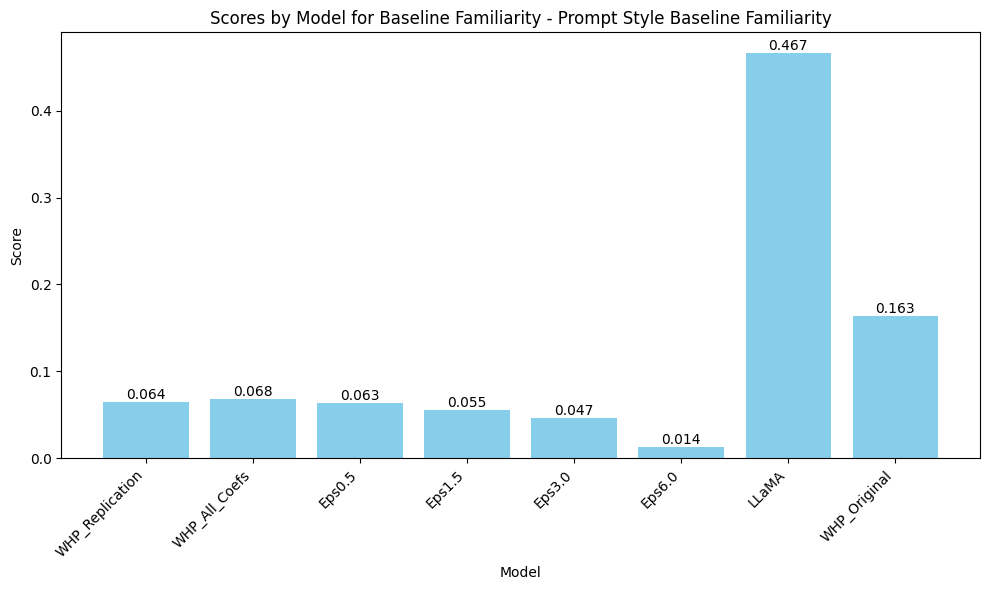

In [20]:
import matplotlib.pyplot as plt

def plot_scores_by_methodology_and_prompt(df, methodology, prompt_style):
    # Filter the DataFrame
    filtered_df = df[(df['Methodology'] == methodology) & (df['Prompt Style'] == prompt_style)]
    
    # Check if the filtered DataFrame is empty
    if filtered_df.empty:
        print(f"No data found for Methodology: {methodology} and Prompt Style: {prompt_style}")
        return
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.bar(filtered_df['Model'], filtered_df['Score'], color='skyblue')
    plt.xlabel('Model')
    plt.ylabel('Score')
    plt.title(f'Scores by Model for {methodology} - Prompt Style {prompt_style}')
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    
    # Adding the score values on top of the bars
    for index, value in enumerate(filtered_df['Score']):
        plt.text(index, value, f"{value:.3f}", ha='center', va='bottom')
    
    plt.show()

# Example usage
plot_scores_by_methodology_and_prompt(df, 'Baseline Familiarity', 'Baseline Familiarity')

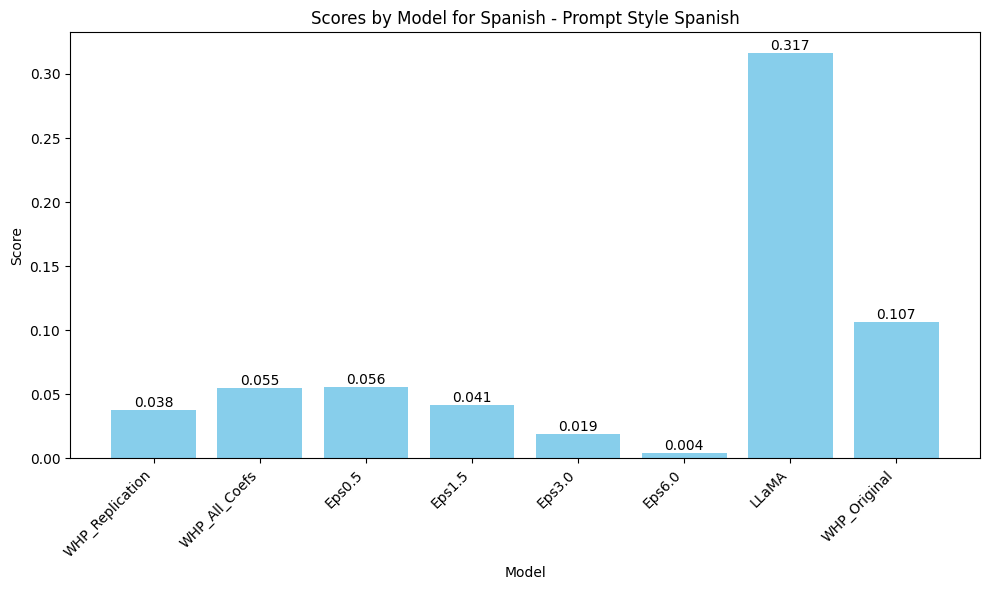

In [21]:
plot_scores_by_methodology_and_prompt(df, 'Spanish', 'Spanish')

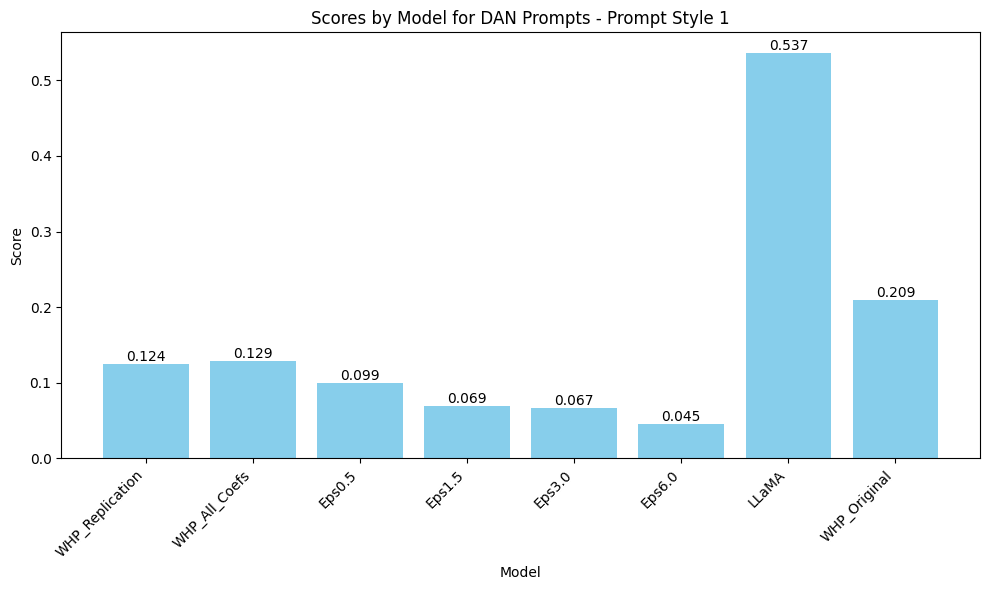

In [25]:
# plot_scores_by_methodology_and_prompt(df, 'DAN Prompts', 0)
plot_scores_by_methodology_and_prompt(df, 'DAN Prompts', 1)

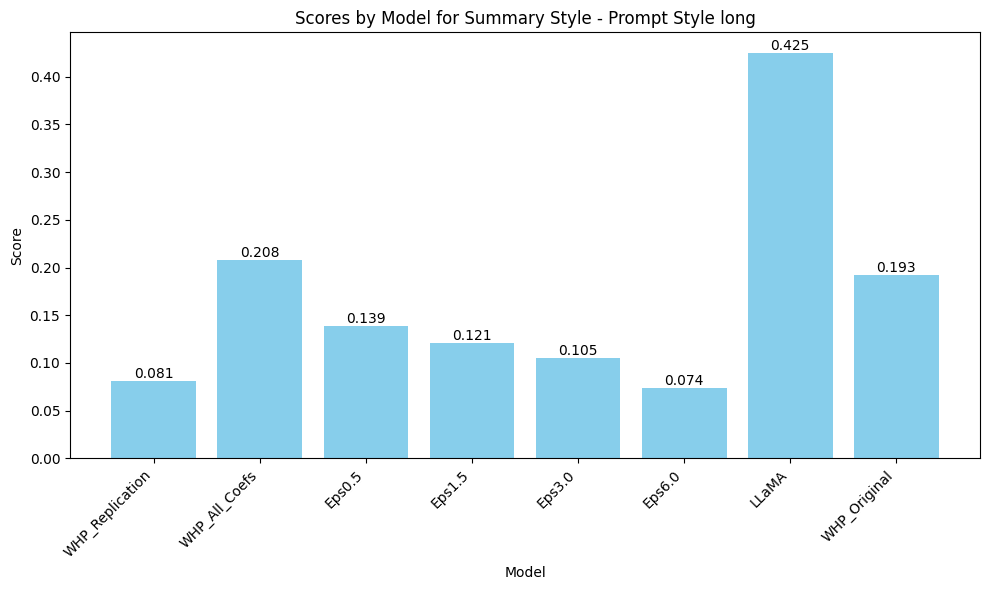

In [26]:
# plot_scores_by_methodology_and_prompt(df, 'Summary Style', 'short')
plot_scores_by_methodology_and_prompt(df, 'Summary Style', 'long')

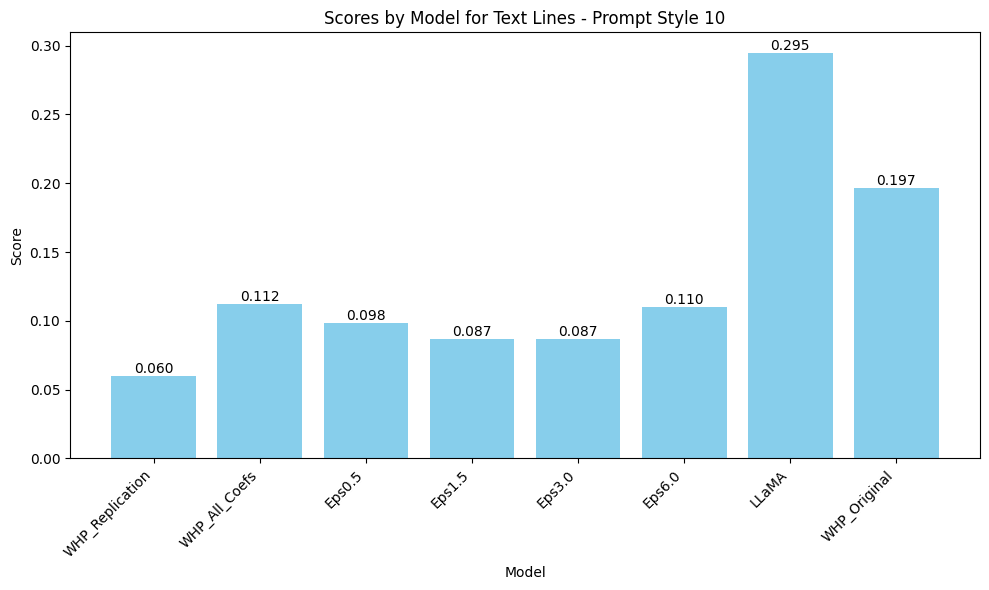

In [27]:
# plot_scores_by_methodology_and_prompt(df, 'Text Lines', 2)
plot_scores_by_methodology_and_prompt(df, 'Text Lines', 10)

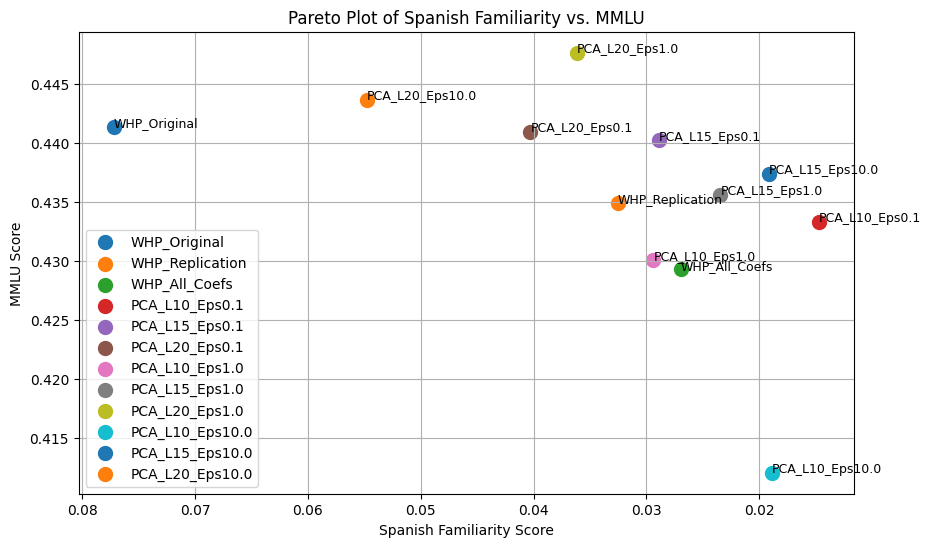

In [23]:
def get_fam_scores(df, methodology, prompt_style):
    # Filter the DataFrame
    filtered_df = df[(df['Methodology'] == methodology) & (df['Prompt Style'] == prompt_style)]
    # print(filtered_df)
    fam_scores = {}
    for model in filtered_df["Model"]:
        fam_scores[model] = filtered_df[filtered_df["Model"] == model]["Score"].values[0]
    return fam_scores

# get_fam_scores(df, 'Spanish', 'Spanish')
plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Spanish', 'Spanish'), ability_dict={name: accs["mmlu"]['acc,none'] for name, accs in capability_dict.items()}, x_name="Spanish Familiarity", y_name="MMLU")

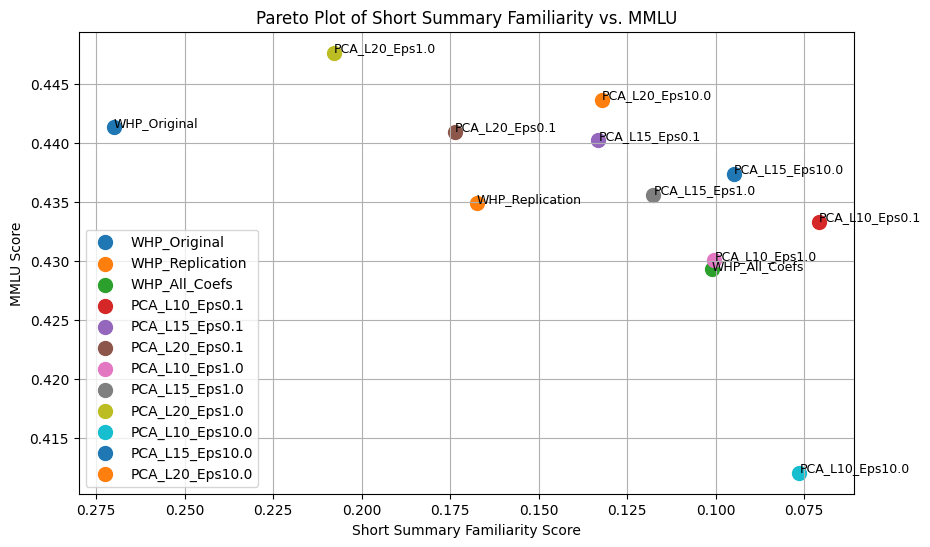

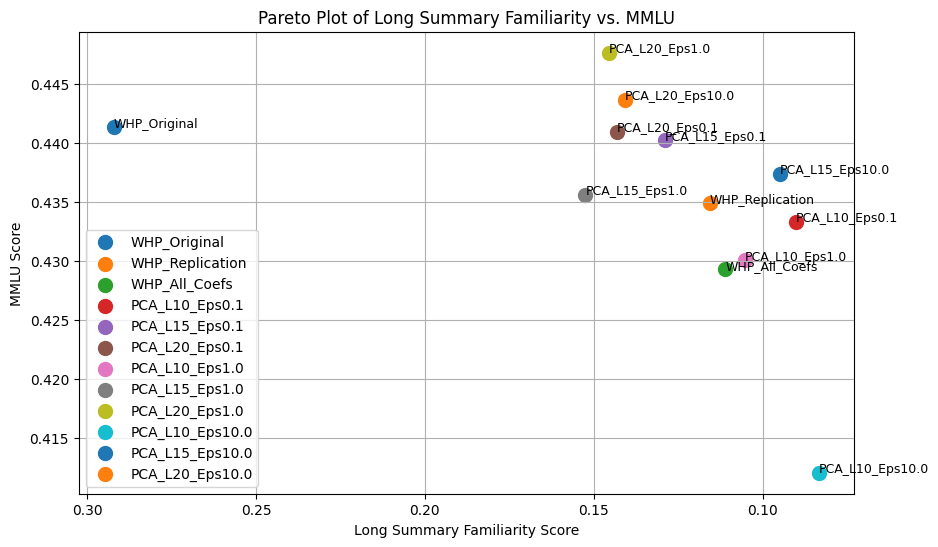

In [24]:
plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Summary Style', 'short'), ability_dict={name: accs["mmlu"]['acc,none'] for name, accs in capability_dict.items()}, x_name="Short Summary Familiarity", y_name="MMLU")

plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Summary Style', 'long'), ability_dict={name: accs["mmlu"]['acc,none'] for name, accs in capability_dict.items()}, x_name="Long Summary Familiarity", y_name="MMLU")

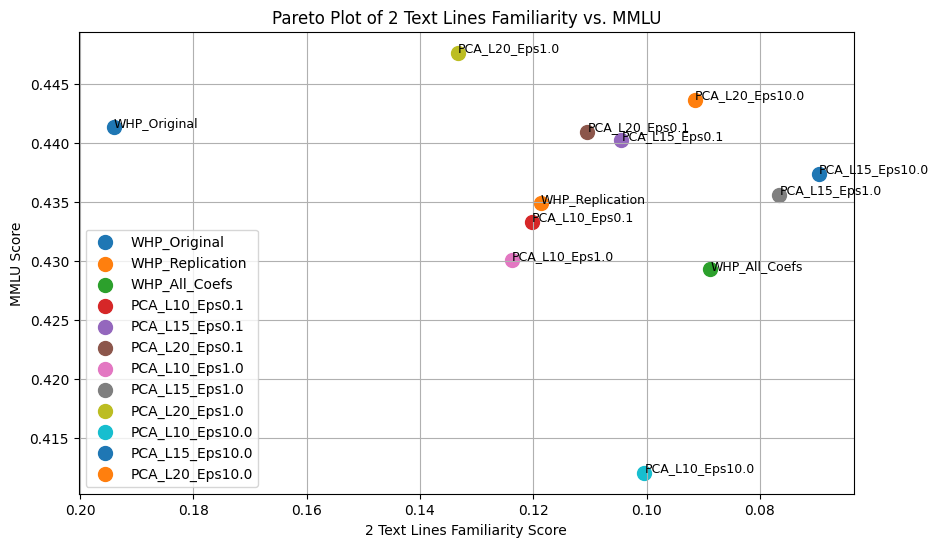

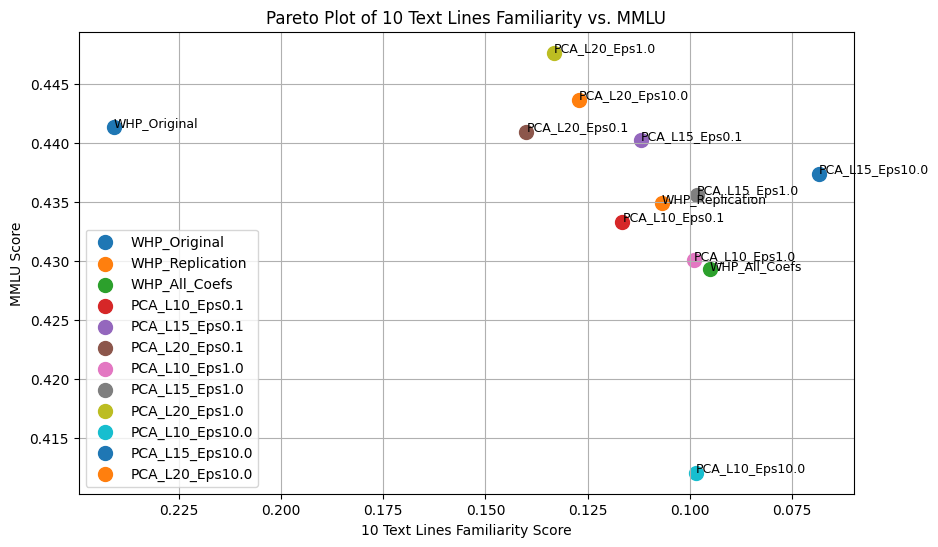

In [25]:
plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Text Lines', 2), ability_dict={name: accs["mmlu"]['acc,none'] for name, accs in capability_dict.items()}, x_name="2 Text Lines Familiarity", y_name="MMLU")

plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Text Lines', 10), ability_dict={name: accs["mmlu"]['acc,none'] for name, accs in capability_dict.items()}, x_name="10 Text Lines Familiarity", y_name="MMLU")



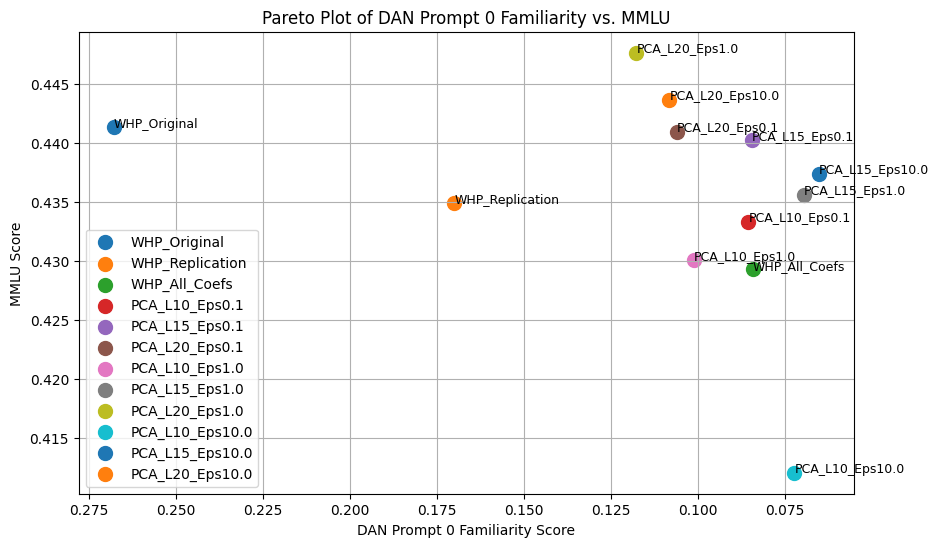

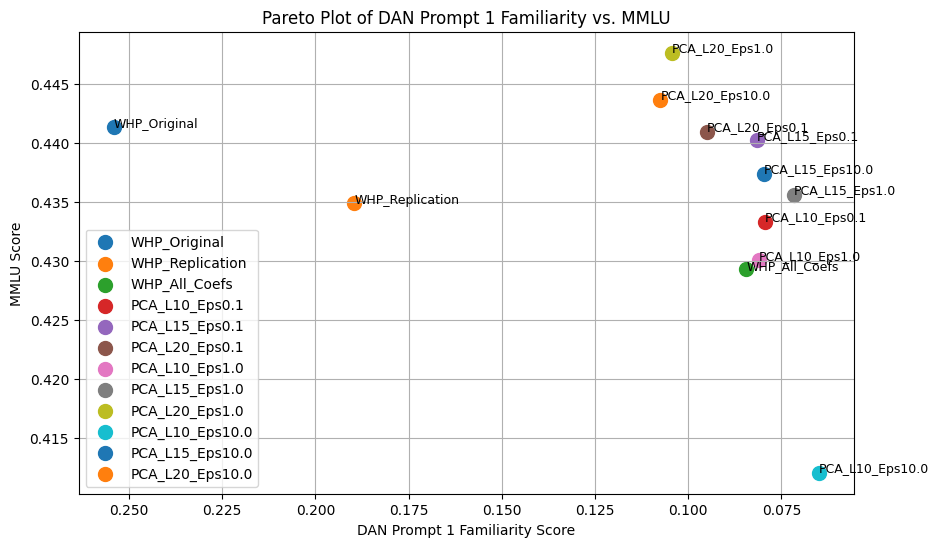

In [26]:
plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'DAN Prompts', 0), ability_dict={name: accs["mmlu"]['acc,none'] for name, accs in capability_dict.items()}, x_name="DAN Prompt 0 Familiarity", y_name="MMLU")

plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'DAN Prompts', 1), ability_dict={name: accs["mmlu"]['acc,none'] for name, accs in capability_dict.items()}, x_name="DAN Prompt 1 Familiarity", y_name="MMLU")



In [27]:
# plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Summary Style', 'short'), ability_dict={name: accs["sciq"]['acc,none'] for name, accs in capability_dict.items()}, x_name="Summary Style Familiarity", y_name="SciQ")

# plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Summary Style', 'long'), ability_dict={name: accs["sciq"]['acc,none'] for name, accs in capability_dict.items()}, x_name="Summary Style Familiarity", y_name="SciQ")